In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [88]:
df = pd.read_csv('../artifacts/raw/data.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [90]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [91]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [92]:
df.duplicated().sum()

np.int64(0)

In [93]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [94]:
df.drop('Id', axis=1, inplace=True)

In [95]:
df.head(1)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa


<Figure size 1000x600 with 0 Axes>

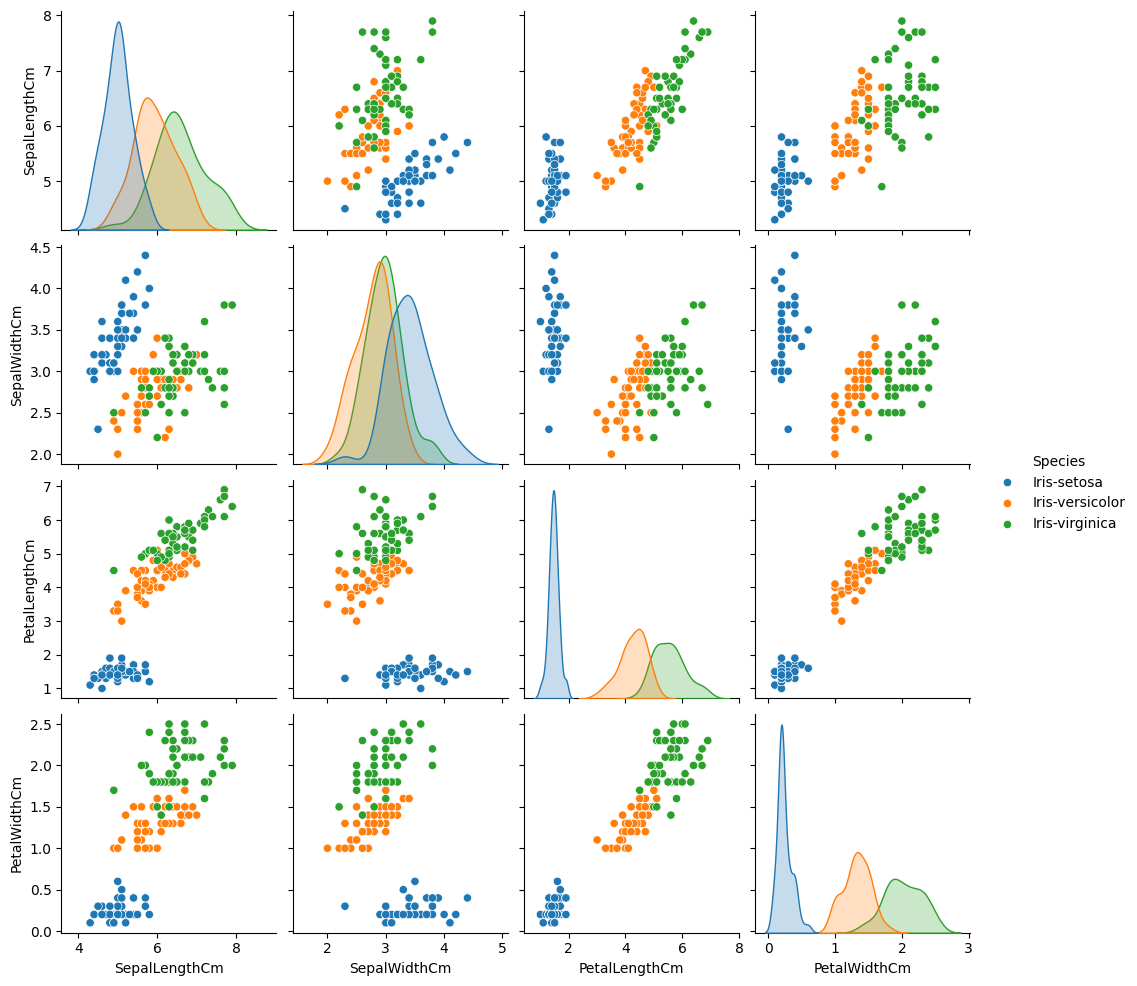

In [96]:
plt.figure(figsize=(10, 6))
sns.pairplot(df, hue='Species')
plt.show()

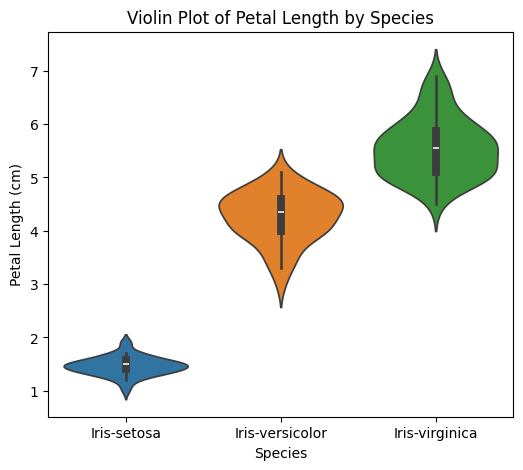

In [97]:
plt.figure(figsize=(6, 5))
sns.violinplot(x='Species', y='PetalLengthCm', data=df, hue='Species')
plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')
plt.title('Violin Plot of Petal Length by Species')
plt.show()

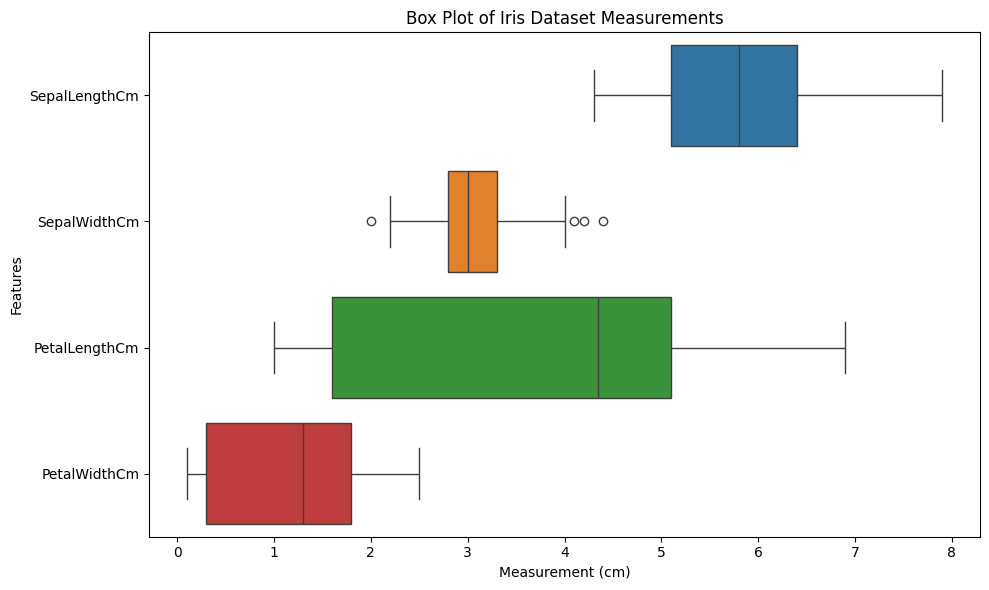

In [98]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, orient='h')
plt.xlabel('Measurement (cm)')
plt.ylabel('Features')
plt.title('Box Plot of Iris Dataset Measurements')
plt.tight_layout()
plt.show()

In [99]:
Q1 = df['SepalWidthCm'].quantile(0.25)
Q3 = df['SepalWidthCm'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sepal_median = df['SepalWidthCm'].median()

imputed_df = df.copy()
imputed_df['SepalWidthCm'] = df['SepalWidthCm'].apply(lambda x: sepal_median if x < lower_bound or x > upper_bound else x)

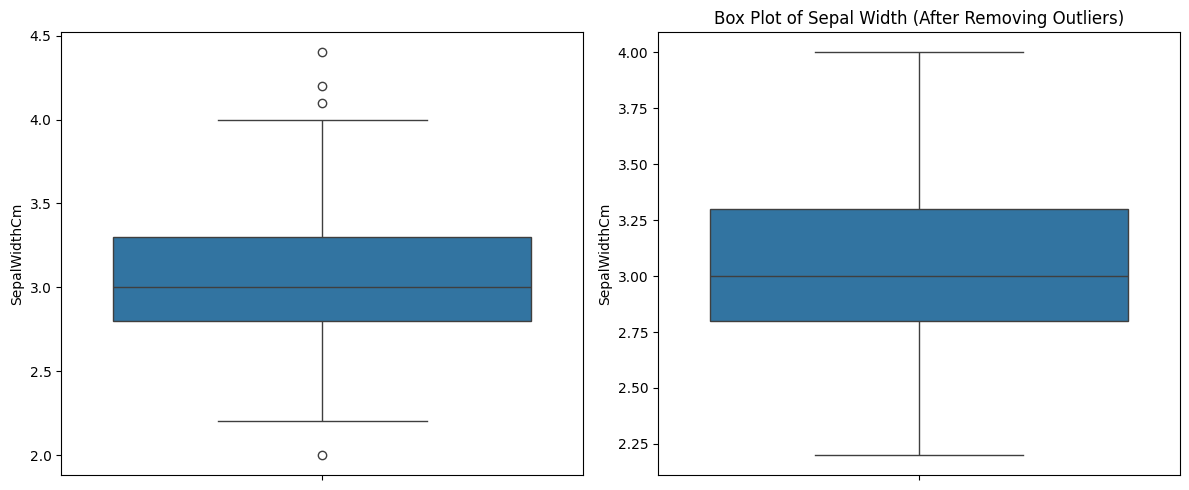

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df['SepalWidthCm'], ax=axes[0])
plt.title('Box Plot of Sepal Width (Before Removing Outliers)')

sns.boxplot(data=imputed_df['SepalWidthCm'], ax=axes[1])
plt.title('Box Plot of Sepal Width (After Removing Outliers)')
plt.tight_layout()
plt.show()


In [101]:
X = imputed_df.drop('Species', axis=1)
y = imputed_df['Species']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [105]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [108]:
model = DecisionTreeClassifier(criterion='gini', max_depth=30, random_state=42)

In [109]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [111]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [131]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importances

,Feature,Importance
0,PetalLengthCm,0.906143
1,PetalWidthCm,0.077186
2,SepalWidthCm,0.016670
3,SepalLengthCm,0.000000


In [112]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


<Axes: >

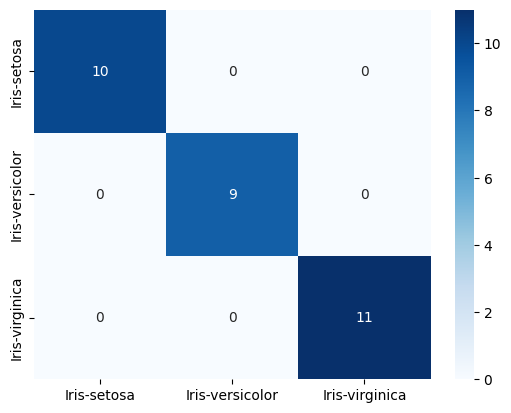

In [125]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)

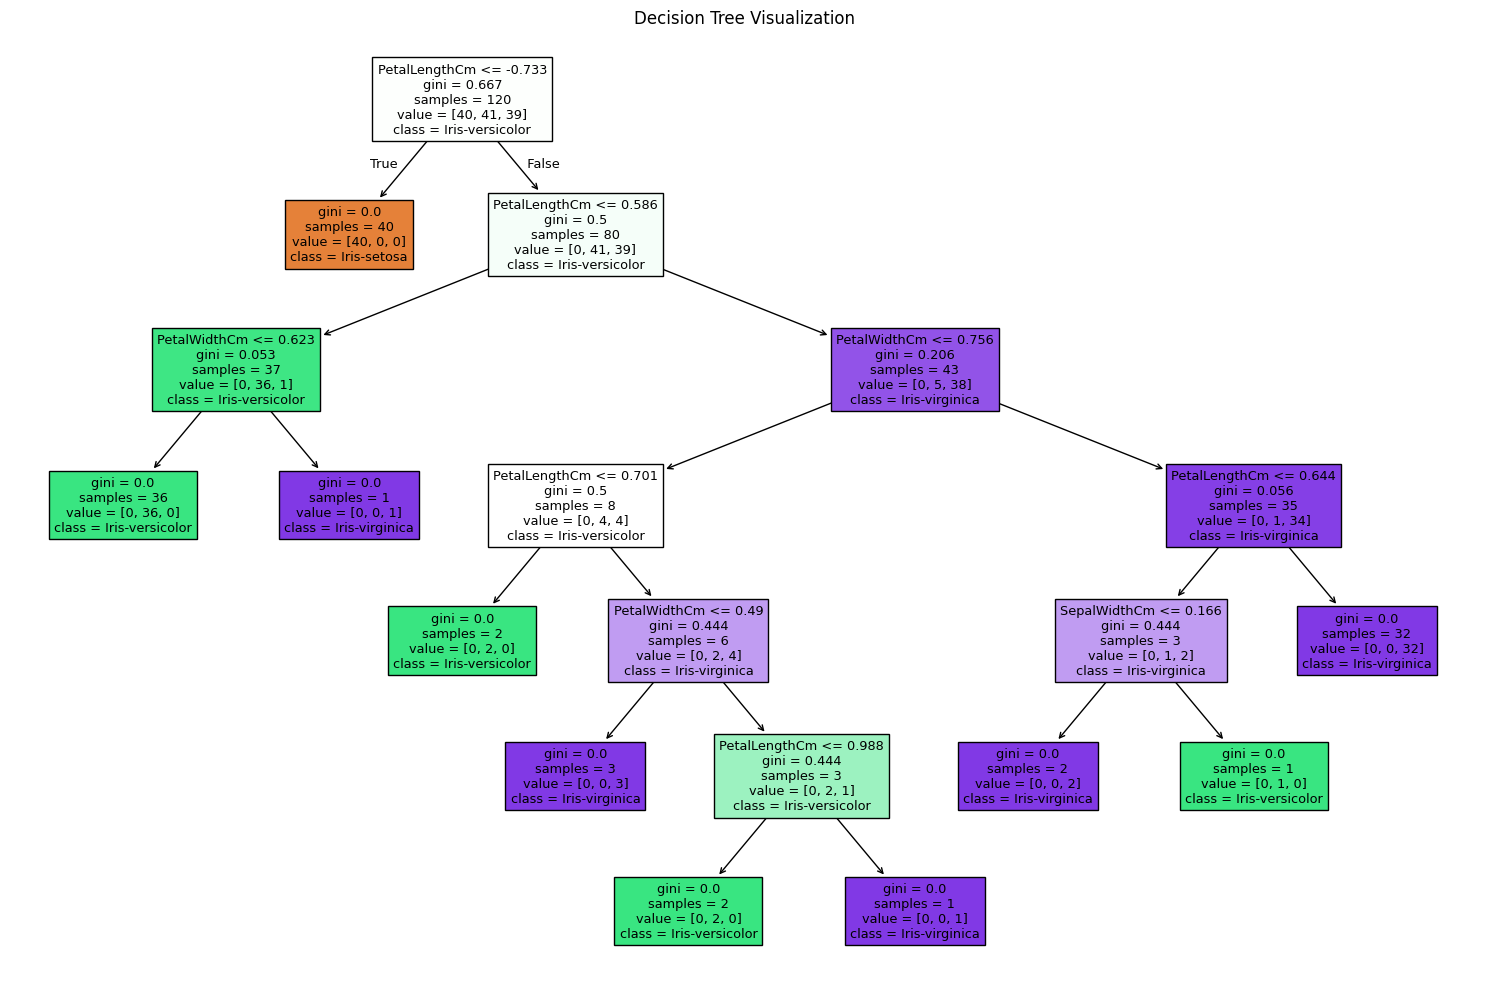

In [ ]:
plt.figure(figsize=(15, 10))
plot_tree(model, feature_names=X.columns, class_names=le.classes_, filled=True)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

In [117]:
sample_data = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)
sample_scaled = scaler.transform(sample_data)
sample_pred = model.predict(sample_scaled)

predicted_species = le.inverse_transform(sample_pred)
print(f'Predicted Species for sample data: {predicted_species[0]}')

Predicted Species for sample data: Iris-setosa
